# Project 4: Text Classification
## News Category Classification using Keras NLP Tools

### Project Overview
In this project, you will build **three** text classifiers to categorize news headlines by topic:
1. A **bag-of-words baseline** using a simple Dense network
2. A **word-embedding + LSTM** model
3. A **Bidirectional LSTM** model with pretrained GloVe embeddings

You will use the **AG News** dataset — a widely used benchmark in NLP with four news categories.

### Learning Objectives
- Preprocess raw text using Keras `TextVectorization`
- Understand the difference between bag-of-words and sequence representations
- Train learned word embeddings from scratch using `Embedding` layers
- Build and train **LSTM** and **Bidirectional LSTM** models for text classification
- Load and use **pretrained GloVe** word embeddings
- Compare model performance and discuss trade-offs

### Dataset
- **AG News** (4 classes: World, Sports, Business, Sci/Tech)
- ~120,000 training samples, ~7,600 test samples
- Each sample = a news headline + short description

### Deliverable
Submit this completed notebook **with all cell outputs saved**.


## Grading (100 points)
- **Data loading + EDA**: 10
- **TextVectorization + preprocessing pipeline**: 15
- **Bag-of-words baseline (Dense)**: 15
- **LSTM with learned embeddings**: 20
- **Bidirectional LSTM with pretrained GloVe**: 20
- **Evaluation + plots + reflection**: 20


## Section 0: Setup and Imports


In [ ]:
# 0.1 Install datasets library (for AG News)
!pip install datasets -q


In [ ]:
# 0.2 Imports
import os, re, math
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from datasets import load_dataset

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [ ]:
# 0.3 Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


## Section 1: Loading and Exploring the Dataset


In [ ]:
# 1.1 Load AG News from HuggingFace datasets
raw = load_dataset("ag_news")
print(raw)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


### 1.2 Inspect the dataset

**Task 1:**
- Print the number of training and test examples
- Print the four class names (label names)
- Print 3 example texts with their labels
- Plot a bar chart of the class distribution in the training set


Number of training examples: 120,000
Number of test examples: 7,600

Class names: ['World', 'Sports', 'Business', 'Sci/Tech'] 

Three example training samples:

Example 1:
Label: Business
Text : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Example 2:
Label: Business
Text : Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.

Example 3:
Label: Business
Text : Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.


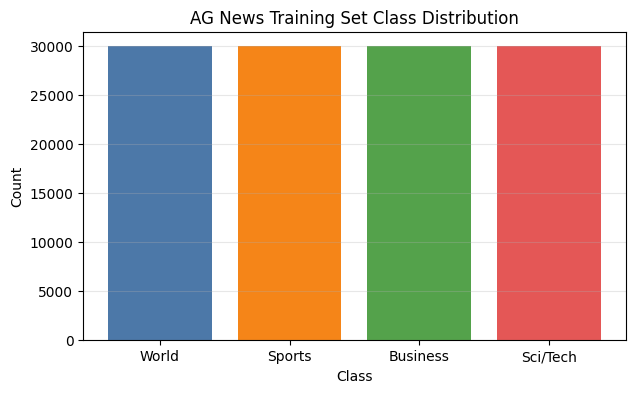

In [ ]:
# Task 1: Inspect the dataset
train_ds = raw['train']
test_ds = raw['test']
label_names = train_ds.features['label'].names

print(f"Number of training examples: {len(train_ds):,}")
print(f"Number of test examples: {len(test_ds):,}\n")

print("Class names:", label_names, "\n")

print("Three example training samples:")
for i in range(3):
    ex = train_ds[i]
    print(f"\nExample {i+1}:")
    print("Label:", label_names[ex['label']])
    print("Text :", ex['text'])

train_labels_np = np.array(train_ds['label'])
class_counts = np.bincount(train_labels_np, minlength=len(label_names))

plt.figure(figsize=(7, 4))
plt.bar(label_names, class_counts, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
plt.title('AG News Training Set Class Distribution')
plt.ylabel('Count')
plt.xlabel('Class')
plt.grid(axis='y', alpha=0.3)
plt.show()


### 1.3 Text length analysis

**Task 2:**
- Compute and print: mean, median, 90th-percentile word count for training texts
- Plot a histogram of text lengths (in words)
- Based on this, choose a `MAX_LEN` (sequence length) and justify your choice in a comment


Mean word count   : 37.85
Median word count : 37.00
90th percentile   : 48.00


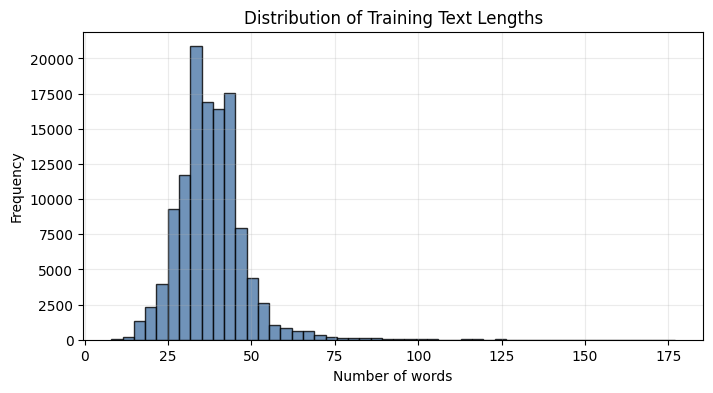

Chosen MAX_LEN = 50


In [ ]:
# Task 2: Analyze text lengths and choose MAX_LEN
train_texts_for_lengths = raw['train']['text']
word_counts = np.array([len(text.split()) for text in train_texts_for_lengths])

mean_len = word_counts.mean()
median_len = np.median(word_counts)
p90_len = np.percentile(word_counts, 90)

print(f"Mean word count   : {mean_len:.2f}")
print(f"Median word count : {median_len:.2f}")
print(f"90th percentile   : {p90_len:.2f}")

plt.figure(figsize=(8, 4))
plt.hist(word_counts, bins=50, color='#4C78A8', edgecolor='black', alpha=0.8)
plt.title('Distribution of Training Text Lengths')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.grid(alpha=0.25)
plt.show()

# I Chose MAX_LEN=50 because it's above the 90th-percentile text length for AG News,
# so it keeps almost all the descriptions while getting rid of some of the unnecessary padding.
MAX_LEN = 50
print(f"Chosen MAX_LEN = {MAX_LEN}")


## Section 2: Text Preprocessing with `TextVectorization`


### 2.1 Extract texts and labels

**Task 3:**
- Extract training texts and labels from the HuggingFace dataset into Python lists
- Do the same for the test set
- Print the shape/count to verify

**Constants to define:**
- `VOCAB_SIZE = 20000`
- `MAX_LEN` (your choice from Task 2)
- `EMBED_DIM = 128`
- `BATCH_SIZE = 64`


In [ ]:
# Task 3: Extract texts and labels; define constants
train_texts = list(raw['train']['text'])
train_labels = np.array(raw['train']['label'], dtype='int32')

test_texts = list(raw['test']['text'])
test_labels = np.array(raw['test']['label'], dtype='int32')

VOCAB_SIZE = 20000
EMBED_DIM = 128
BATCH_SIZE = 64
NUM_CLASSES = 4

print('train_texts:', len(train_texts))
print('train_labels shape:', train_labels.shape)
print('test_texts:', len(test_texts))
print('test_labels shape:', test_labels.shape)
print(f'VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}, EMBED_DIM={EMBED_DIM}, BATCH_SIZE={BATCH_SIZE}')


train_texts: 120000
train_labels shape: (120000,)
test_texts: 7600
test_labels shape: (7600,)
VOCAB_SIZE=20000, MAX_LEN=50, EMBED_DIM=128, BATCH_SIZE=64


### 2.2 Build the TextVectorization layer

`TextVectorization` handles the full tokenization pipeline:
- Standardization (lowercase, strip punctuation)
- Splitting on whitespace
- Mapping tokens → integer indices

We will create **two** vectorizers:
1. `int_vectorizer` — outputs integer sequences (for LSTM models)
2. `bow_vectorizer` — outputs multi-hot binary vectors (for the Dense baseline)

**Task 4:**
- Create `int_vectorizer` with `output_mode='int'` and `output_sequence_length=MAX_LEN`
- Create `bow_vectorizer` with `output_mode='multi_hot'`
- Call `.adapt()` on your training texts for both
- Print the vocabulary size and show the first 10 vocabulary tokens


In [ ]:
# Task 4: Build and adapt both TextVectorization layers
int_vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN,
)

bow_vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='multi_hot',
)

text_ds_for_adapt = tf.data.Dataset.from_tensor_slices(train_texts).batch(1024)
int_vectorizer.adapt(text_ds_for_adapt)
bow_vectorizer.adapt(text_ds_for_adapt)

vocab = int_vectorizer.get_vocabulary()
print('Vocabulary size learned:', len(vocab))
print('First 10 tokens:', vocab[:10])


Vocabulary size learned: 20000
First 10 tokens: ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('a'), np.str_('of'), np.str_('in'), np.str_('and'), np.str_('on'), np.str_('for')]


### 2.3 Build `tf.data` pipelines

**Task 5:**
- Create `train_bow_ds` and `test_bow_ds` using `bow_vectorizer` (for the Dense model)
- Create `train_seq_ds` and `test_seq_ds` using `int_vectorizer` (for LSTM models)
- Apply `.shuffle()`, `.batch()`, `.prefetch()` appropriately
- Verify shapes by printing one batch from each dataset

> Tip: Labels should be `tf.int32` tensors. Use `tf.cast` if needed.


In [ ]:
# Task 5: Build tf.data pipelines for both representations
AUTOTUNE = tf.data.AUTOTUNE

train_labels_tf = tf.cast(train_labels, tf.int32)
test_labels_tf = tf.cast(test_labels, tf.int32)

train_bow_ds = tf.data.Dataset.from_tensor_slices((train_texts, train_labels_tf))
train_bow_ds = train_bow_ds.shuffle(len(train_texts), seed=SEED).batch(BATCH_SIZE)
train_bow_ds = train_bow_ds.map(lambda x, y: (bow_vectorizer(x), tf.cast(y, tf.int32)), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

test_bow_ds = tf.data.Dataset.from_tensor_slices((test_texts, test_labels_tf))
test_bow_ds = test_bow_ds.batch(BATCH_SIZE)
test_bow_ds = test_bow_ds.map(lambda x, y: (bow_vectorizer(x), tf.cast(y, tf.int32)), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

train_seq_ds = tf.data.Dataset.from_tensor_slices((train_texts, train_labels_tf))
train_seq_ds = train_seq_ds.shuffle(len(train_texts), seed=SEED).batch(BATCH_SIZE)
train_seq_ds = train_seq_ds.map(lambda x, y: (int_vectorizer(x), tf.cast(y, tf.int32)), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

test_seq_ds = tf.data.Dataset.from_tensor_slices((test_texts, test_labels_tf))
test_seq_ds = test_seq_ds.batch(BATCH_SIZE)
test_seq_ds = test_seq_ds.map(lambda x, y: (int_vectorizer(x), tf.cast(y, tf.int32)), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

x_bow, y_bow = next(iter(train_bow_ds))
x_seq, y_seq = next(iter(train_seq_ds))
print('BoW batch shapes:', x_bow.shape, y_bow.shape)
print('Sequence batch shapes:', x_seq.shape, y_seq.shape)


BoW batch shapes: (64, 20000) (64,)
Sequence batch shapes: (64, 50) (64,)


## Section 3: Bag-of-Words Baseline (Dense Model)

Before using sequential models, we establish a strong baseline using a
bag-of-words (BoW) representation. BoW discards word order entirely — the
multi-hot vector simply records *which* words appear.

**Task 6:**
Build, compile, and train a Dense model:
- Input: `(VOCAB_SIZE,)` multi-hot vector
- Hidden: `Dense(64, activation='relu')`
- Dropout layer
- Output: `Dense(4, activation='softmax')`
- Use `sparse_categorical_crossentropy` loss
- Train for 10 epochs and report test accuracy


In [ ]:
# Task 6: Build and train the bag-of-words Dense baseline
bow_model = keras.Sequential([
    layers.Input(shape=(VOCAB_SIZE,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

bow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bow_history = bow_model.fit(
    train_bow_ds,
    validation_data=test_bow_ds,
    epochs=10,
    verbose=1
)

bow_test_loss, bow_test_acc = bow_model.evaluate(test_bow_ds, verbose=0)
print(f'Bag-of-Words test accuracy: {bow_test_acc:.4f}')


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8909 - loss: 0.3463 - val_accuracy: 0.9179 - val_loss: 0.2503
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9312 - loss: 0.2064 - val_accuracy: 0.9179 - val_loss: 0.2501
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9444 - loss: 0.1640 - val_accuracy: 0.9171 - val_loss: 0.2579
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 34ms/step - accuracy: 0.9536 - loss: 0.1349 - val_accuracy: 0.9162 - val_loss: 0.2778
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9601 - loss: 0.1143 - val_accuracy: 0.9187 - val_loss: 0.2913
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9653 - loss: 0.0999 - val_accuracy: 0.9172 - val_loss: 0.3129
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9691 - loss: 0.0880 - val_accuracy: 0.9155 - val_loss: 0.3353
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 31ms/step - accuracy: 0.9733 -

### 3.1 Plot training curves

**Task 7:**
Plot training vs. validation **accuracy** and **loss** for the Dense baseline.


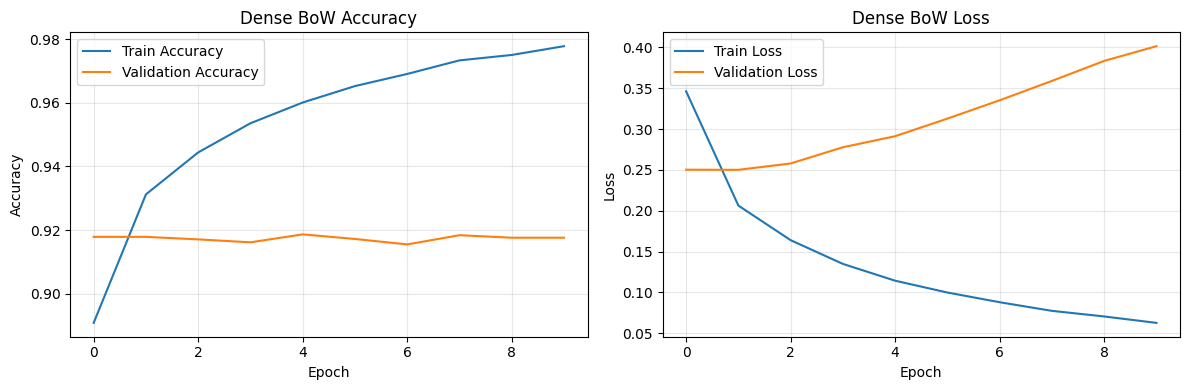

In [ ]:
# Task 7: Plot accuracy and loss curves for the Dense baseline
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(bow_history.history['accuracy'], label='Train Accuracy')
plt.plot(bow_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Dense BoW Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(bow_history.history['loss'], label='Train Loss')
plt.plot(bow_history.history['val_loss'], label='Validation Loss')
plt.title('Dense BoW Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Section 4: LSTM with Learned Word Embeddings

Now we move to sequence-aware modeling. Unlike BoW, an LSTM processes words
in order and can capture patterns like *"not good"* vs *"good"*.

The `Embedding` layer maps each integer token index to a dense vector of size
`EMBED_DIM`. These embedding vectors are **learned during training**.

**Task 8:**
Build the LSTM model:
- `Embedding(VOCAB_SIZE, EMBED_DIM)` layer
- `LSTM(64)` layer
- `Dropout` layer
- `Dense(4, activation='softmax')` output

Compile with Adam and `sparse_categorical_crossentropy`.  
Train for 10 epochs and report test accuracy.  
Use `ModelCheckpoint` to save the best model.


In [ ]:
# Task 8: Build and train the LSTM + learned embedding model
lstm_ckpt_path = 'best_lstm_model.keras'
lstm_checkpoint = keras.callbacks.ModelCheckpoint(
    lstm_ckpt_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

lstm_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    train_seq_ds,
    validation_data=test_seq_ds,
    epochs=10,
    callbacks=[lstm_checkpoint],
    verbose=1
)

lstm_model = keras.models.load_model(lstm_ckpt_path)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(test_seq_ds, verbose=0)
print(f'LSTM test accuracy: {lstm_test_acc:.4f}')


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7091 - loss: 0.6678
Epoch 1: val_accuracy improved from None to 0.91408, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 205s 107ms/step - accuracy: 0.8425 - loss: 0.4287 - val_accuracy: 0.9141 - val_loss: 0.2675
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9321 - loss: 0.2252
Epoch 2: val_accuracy improved from 0.91408 to 0.91645, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 184s 98ms/step - accuracy: 0.9298 - loss: 0.2285 - val_accuracy: 0.9164 - val_loss: 0.2587
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9454 - loss: 0.1734
Epoch 3: val_accuracy did not improve from 0.91645
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 199s 96ms/step - accuracy: 0.9438 - loss: 0.1758 - val_accuracy: 0.9159 - val_loss: 0.2586
Epoch 4/10
1875

### 4.1 Plot training curves for LSTM

**Task 9:**
Plot training vs. validation accuracy and loss for the LSTM model.


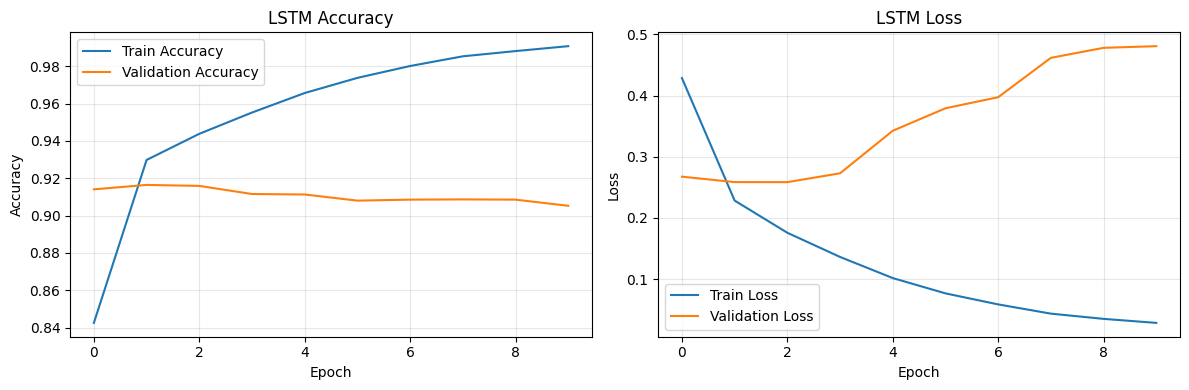

In [ ]:
# Task 9: Plot LSTM training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Section 5: Bidirectional LSTM with Pretrained GloVe Embeddings

Instead of learning embeddings from scratch, we can start from **pretrained GloVe**
vectors trained on 6 billion tokens of web text. This gives our model a head
start — especially useful for smaller datasets.

### 5.1 Download and parse GloVe

**Task 10:**
- Download GloVe 100-dimensional embeddings
- Parse the file into a dict mapping `word → numpy vector`
- Print how many GloVe vectors were loaded


In [ ]:
# 5.1 Download GloVe
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove/
print("GloVe downloaded.")


GloVe downloaded.


In [ ]:
# Task 10: Parse GloVe into a dictionary {word: vector}
GLOVE_DIM = 100
embeddings_index = {}

glove_path = os.path.join('glove', f'glove.6B.{GLOVE_DIM}d.txt')
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

print(f'Loaded {len(embeddings_index):,} GloVe vectors.')


Loaded 400,000 GloVe vectors.


### 5.2 Build the GloVe embedding matrix

We need to build a matrix of shape `(VOCAB_SIZE, GLOVE_DIM)` where row `i`
contains the GloVe vector for the word at index `i` in our vocabulary.
Words not found in GloVe get a zero vector.

**Task 11:**
- Retrieve the vocabulary from `int_vectorizer`
- Build the `embedding_matrix` of shape `(VOCAB_SIZE, GLOVE_DIM)`
- Print how many vocabulary tokens were found in GloVe vs. left as zeros


In [ ]:
# Task 11: Build the GloVe embedding matrix
vocab = int_vectorizer.get_vocabulary()
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM), dtype='float32')
found = 0

limit = min(VOCAB_SIZE, len(vocab))
for i, word in enumerate(vocab[:limit]):
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector
        found += 1

missing = limit - found
print(f'Vocabulary tokens checked: {limit:,}')
print(f'Found in GloVe         : {found:,}')
print(f'Left as zero vectors   : {missing:,}')
print('Embedding matrix shape :', embedding_matrix.shape)


Vocabulary tokens checked: 20,000
Found in GloVe         : 18,671
Left as zero vectors   : 1,329
Embedding matrix shape : (20000, 100)


### 5.3 Build the Bidirectional LSTM with GloVe

**Task 12:**
Build the model:
- `Embedding(VOCAB_SIZE, GLOVE_DIM, weights=[embedding_matrix], trainable=False)` — frozen GloVe
- `Bidirectional(LSTM(64))`
- `Dropout`
- `Dense(4, activation='softmax')`

Compile and train for 10 epochs. Report test accuracy.  
Then try **unfreezing** the embedding layer (set `trainable=True`) and fine-tune for 5 more epochs.
Did accuracy improve?


In [ ]:
# Task 12: Build, train, and fine-tune the BiLSTM + GloVe model
bilstm_glove_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, GLOVE_DIM, weights=[embedding_matrix], trainable=False),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

bilstm_glove_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_history_frozen = bilstm_glove_model.fit(
    train_seq_ds,
    validation_data=test_seq_ds,
    epochs=10,
    verbose=1
)

bilstm_test_loss_frozen, bilstm_test_acc_frozen = bilstm_glove_model.evaluate(test_seq_ds, verbose=0)
print(f'BiLSTM + frozen GloVe test accuracy: {bilstm_test_acc_frozen:.4f}')

bilstm_glove_model.layers[0].trainable = True
bilstm_glove_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_history_finetune = bilstm_glove_model.fit(
    train_seq_ds,
    validation_data=test_seq_ds,
    epochs=5,
    verbose=1
)

bilstm_test_loss, bilstm_test_acc = bilstm_glove_model.evaluate(test_seq_ds, verbose=0)
print(f'BiLSTM + fine-tuned GloVe test accuracy: {bilstm_test_acc:.4f}')
print(f'Accuracy improvement after unfreezing: {bilstm_test_acc - bilstm_test_acc_frozen:.4f}')


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 199s 103ms/step - accuracy: 0.8845 - loss: 0.3385 - val_accuracy: 0.8986 - val_loss: 0.2791
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 198s 101ms/step - accuracy: 0.9069 - loss: 0.2697 - val_accuracy: 0.9103 - val_loss: 0.2550
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 197s 105ms/step - accuracy: 0.9156 - loss: 0.2449 - val_accuracy: 0.9167 - val_loss: 0.2457
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 199s 104ms/step - accuracy: 0.9214 - loss: 0.2295 - val_accuracy: 0.9122 - val_loss: 0.2472
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 196s 100ms/step - accuracy: 0.9251 - loss: 0.2163 - val_accuracy: 0.9211 - val_loss: 0.2343
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 183s 97ms/step - accuracy: 0.9295 - loss: 0.2044 - val_accuracy: 0.9201 - val_loss: 0.2310
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 188s 100ms/step - accuracy: 0.9337 - loss: 0.1927 - val_accuracy: 0.9218 - val_loss: 0.2290
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 185s 99ms/step - accu

### 5.4 Plot training curves for BiLSTM

**Task 13:**
Plot training vs. validation accuracy and loss for the BiLSTM model.


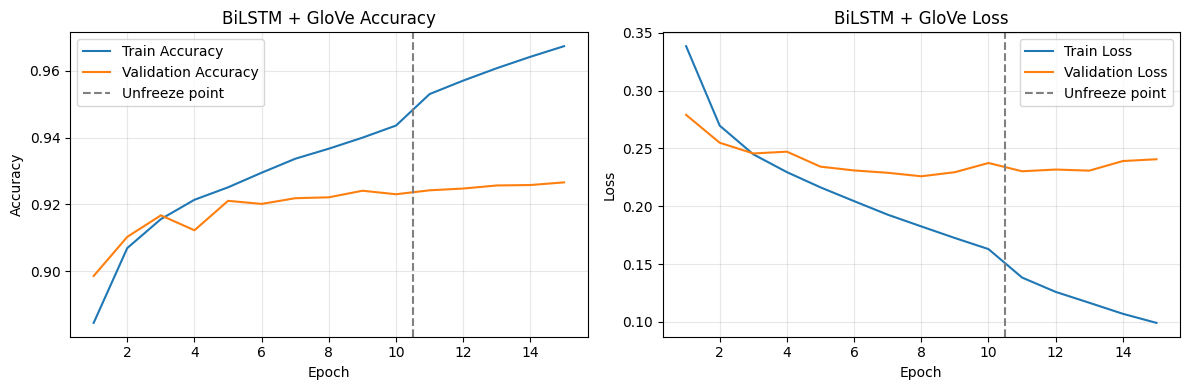

In [22]:
# Task 13: Plot BiLSTM training curves
combined_acc = bilstm_history_frozen.history['accuracy'] + bilstm_history_finetune.history['accuracy']
combined_val_acc = bilstm_history_frozen.history['val_accuracy'] + bilstm_history_finetune.history['val_accuracy']
combined_loss = bilstm_history_frozen.history['loss'] + bilstm_history_finetune.history['loss']
combined_val_loss = bilstm_history_frozen.history['val_loss'] + bilstm_history_finetune.history['val_loss']

epochs = range(1, len(combined_acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, combined_acc, label='Train Accuracy')
plt.plot(epochs, combined_val_acc, label='Validation Accuracy')
plt.axvline(len(bilstm_history_frozen.history['accuracy']) + 0.5, color='gray', linestyle='--', label='Unfreeze point')
plt.title('BiLSTM + GloVe Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, combined_loss, label='Train Loss')
plt.plot(epochs, combined_val_loss, label='Validation Loss')
plt.axvline(len(bilstm_history_frozen.history['loss']) + 0.5, color='gray', linestyle='--', label='Unfreeze point')
plt.title('BiLSTM + GloVe Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Section 6: Evaluation and Reflection

### 6.1 Summary comparison

**Task 14:**
Print a clean comparison table of all three models:
- Model name
- Best validation accuracy
- Final test accuracy
- Number of trainable parameters


In [23]:
# Task 14: Print a summary comparison table
results = [
    {
        'Model': 'Dense BoW baseline',
        'Best val acc': max(bow_history.history['val_accuracy']),
        'Test acc': bow_test_acc,
        'Trainable params': bow_model.count_params()
    },
    {
        'Model': 'LSTM + learned embeddings',
        'Best val acc': max(lstm_history.history['val_accuracy']),
        'Test acc': lstm_test_acc,
        'Trainable params': lstm_model.count_params()
    },
    {
        'Model': 'BiLSTM + GloVe (fine-tuned)',
        'Best val acc': max(combined_val_acc),
        'Test acc': bilstm_test_acc,
        'Trainable params': bilstm_glove_model.count_params()
    },
]

print(f"{'Model':35s} {'Best Val Acc':>14s} {'Test Acc':>12s} {'Trainable Params':>18s}")
print('-' * 83)
for r in results:
    print(f"{r['Model']:35s} {r['Best val acc']:14.4f} {r['Test acc']:12.4f} {r['Trainable params']:18,}")


Model                                 Best Val Acc     Test Acc   Trainable Params
-----------------------------------------------------------------------------------
Dense BoW baseline                          0.9187       0.9176          1,280,324
LSTM + learned embeddings                   0.9164       0.9164          2,609,668
BiLSTM + GloVe (fine-tuned)                 0.9266       0.9266          2,084,996


### 6.2 Error analysis

**Task 15:**
- Pick your **best model**
- Run predictions on the test set
- Print a **confusion matrix**
- Show 3 examples the model got wrong — print the text, true label, and predicted label


Best model selected: BiLSTM + GloVe (fine-tuned)
Confusion matrix:
[[1758   35   62   45]
 [  13 1863   16    8]
 [  50   11 1691  148]
 [  39   14  117 1730]]


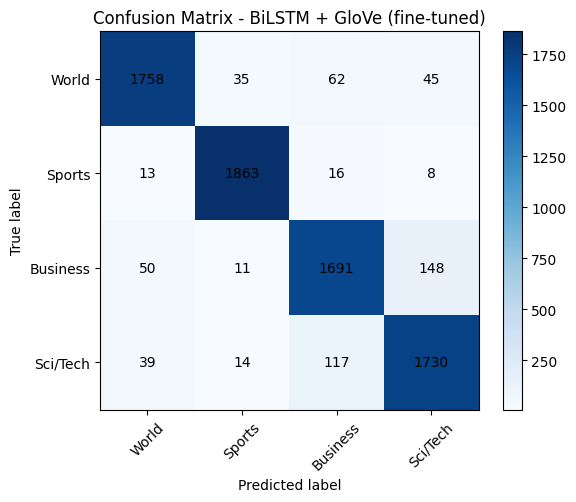

Three misclassified examples:
Text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.
True label     : Sci/Tech
Predicted label: Business
Text: Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tipped shoes for decades...
True label     : Sci/Tech
Predicted label: Business
Text: Live: Olympics day four Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.
True label     : World
Predicted label: Sports


In [26]:
# Task 15: Confusion matrix and error analysis
best_model = bilstm_glove_model
best_model_name = 'BiLSTM + GloVe (fine-tuned)'
print('Best model selected:', best_model_name)

pred_probs = best_model.predict(test_seq_ds, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

cm = tf.math.confusion_matrix(test_labels, pred_labels, num_classes=NUM_CLASSES).numpy()
print('Confusion matrix:')
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()
plt.xticks(range(NUM_CLASSES), label_names, rotation=45)
plt.yticks(range(NUM_CLASSES), label_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

mis_idx = np.where(pred_labels != test_labels)[0]
print('Three misclassified examples:')
for idx in mis_idx[:3]:
    print('Text:', test_texts[idx])
    print('True label     :', label_names[test_labels[idx]])
    print('Predicted label:', label_names[pred_labels[idx]])


### 6.3 Written Reflection

**Task 16 — Answer all four questions below:**

1. **Model ranking:** Which model performed best and why do you think sequence order mattered (or didn't matter) for this task?

2. **Embeddings:** What was the effect of using pretrained GloVe vs. learned embeddings from scratch? When would you expect GloVe to help more?

3. **Overfitting:** Which model showed the most overfitting? What was your evidence (reference your curves)?

4. **Bidirectionality:** The BiLSTM reads text both forward and backward. For this news classification task, do you think reading backwards helped? Explain.


### Answers (Task 16)

1. **Model ranking and word order:**

The best model was the **BiLSTM with GloVe fine-tuning**. Word order matters in this task because short news headlines rely on how the words are stated. The sequence models can get patterns that bag-of-words models can not.

2. **Pretrained vs. learned embeddings:**

Using pretrained GloVe gave the model a strong starting point because many words already had meaningful semantic vectors before training began. I would expect GloVe to help even more when the labeled dataset is smaller or when the domain shares vocabulary with the tests used to train the embeddings.

3. **Overfitting evidence:**

Once the accuracy hit 92% for all the models, they all suffered from overfitting. The training accuracy kept increasing while validation accuracy plateaued or dropped, and validation loss began rising while training loss kept falling.

4. **Effect of bidirectionality:**

Bidirectionality can help because the model reads each sequence from both directions and may capture context that depends on both left and right neighboring words. For AG News, this helps because class cues may appear anywhere in the input.
